<a href="https://colab.research.google.com/github/yunju-1118/ESAA/blob/OB/ESAA_OB_week13_1_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **시계열 분석**


## **1. 시계열 문제**

**시계열 분석**이란 시간에 따라 변하는 데이터를 사용하여 추이를 분석하는 것이다. 예를 들어, **주가/환율 변동 및 기온/습도 변화** 등이 대표적인 시계열 분석이다. 즉, 추세를 파악하거나 향후 전망 등을 예측하기 위한 용도로 시계열 분석을 사용한다.

- **불규칙 변동(irregular variation)**: 시계열 자료에서 시간에 따른 규칙적인 움직임과 달리 어떤 규칙성이 없어 예측 불가능하고 우연적으로 발생하는 변동을 의미한다. (전쟁, 홍수, 화재, 지진, 파업 등)

- **추세 변동(trend variation)**: 시계열 자료가 갖는 장기적인 변화 추세를 의미한다. (국내총생산(GDP), 인구증가율 등)

- **순환 변동(cyclical variation)**: 대체로 2~3년 정도의 일정한 기간을 주기로 순환적으로 나타나는 변동을 의미한다.

- **계절 변동(seasonal variation)**: 시계열 자료에서 보통 계절적 영향과 사회적 관습에 따라 1년 주기로 발생하는 것을 의미한다.

결국 시계열 데이터는 규칙적 시계열과 불규칙적 시계열로 나눌 수 있다. 규칙적 시계열은 트렌드와 분산이 불변하는 데이터이며, 불규칙적 시계열은 트렌드 혹은 분산이 변화하는 시계열 데이터이다. 시계열 데이터를 잘 분석한다는 것은 불규칙성을 갖는 시계열 데이터에 특정한 기법이나 모델을 적용하여 규칙적 패턴을 찾거나 예측하는 것을 의미한다. 불규칙적 시계열에 규칙성을 부여하는 방법으로는 AR, MA, ARMA, ARIMA 모델을 적용하는 것이 가장 널리 알려져있으나, 최근에는 딥러닝을 이용하는 방법이 더 좋은 성능을 내고 있다.

## **2. AR, MA, ARMA, ARIMA**

### **2.1. AR 모델**

AR(AutoRegressive) 모델은 이전 관측 값이 이후 관측 값에 영향을 준다는 아이디어에 대한 모형으로 자기 회귀 모델이라고도 한다.


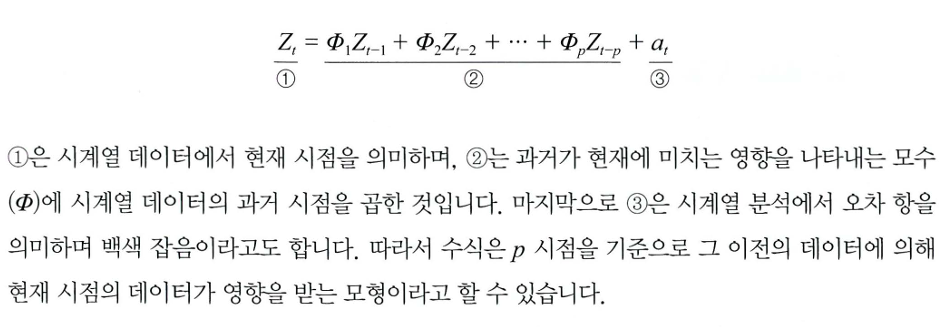

### **2.2. MA 모델**

MA(Moving Average) 모델은 트렌드가 변화하는 상황에 적합한 회귀 모델이다. 이동 평균 모델에서는 윈도우라는 개념을 사용하는데, 시계열을 따라 윈도우 크기만큼 슬라이딩 된다고 하여 이동 평균 모델이라고 한다.

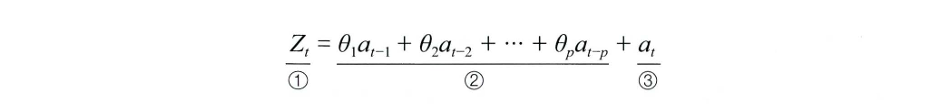

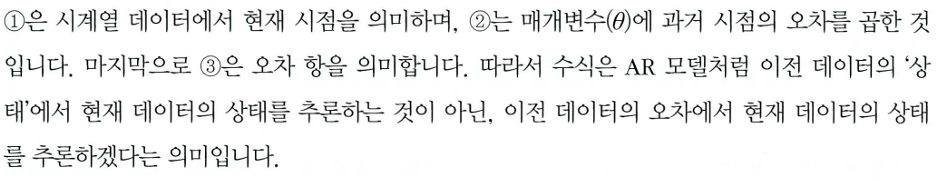

### **2.3. ARMA 모델**

ARMA(AutoRegressive Moving Average) 모델은 AR과 MA를 섞은 모델로 연구 기관에서 주로 사용한다. 수식은 다음과 같다.

$$Z_t = a + \Phi_1Z_{t-1} + … + \Phi_pZ_{t-p} + \theta_1a_{t-1} + \dots + \theta_qa_{t-q} + a_t $$

### **2.4. ARIMA 모델**

ARIMA(AutoRegressive Integrated Moving Average) 모델은 자기 회귀와 이동 평균을 둘 다 고려하는 모형으로, ARMA와 달리 과거 데이터의 선형 관계뿐만 아니라 추세까지 고려한 모델이다.

/tmp/ipython-input-2841192922.py:12: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0,
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -199.651
Date:                Mon, 24 Nov 2025   AIC                            411.302
Time:                        13:43:19   BIC                            420.634
Sample:                    01-01-1991   HQIC                           414.523
                         - 12-01-1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8788      0.227     -3.876      0.000      -1.323      -0.434
ar.L2         -0.2787      0.232     -1.203      0.229      -0.733       0.176
ar.L3         -0.0076      0.270     -0.028      0.9

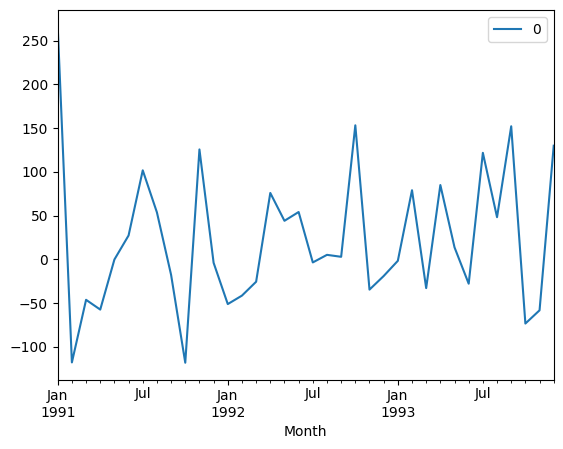

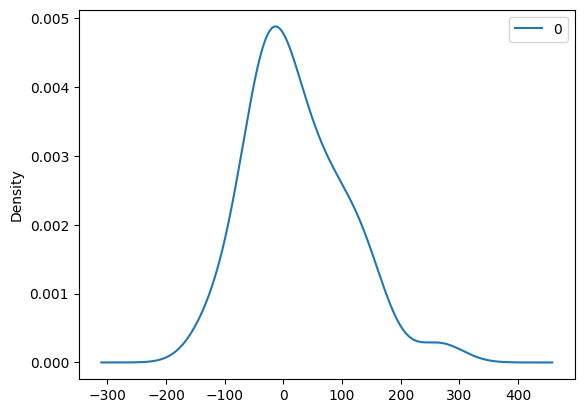

                0
count   36.000000
mean    22.459086
std     82.505331
min   -118.213281
25%    -33.308343
50%      1.361178
75%     76.704967
max    266.000000


In [6]:
# ARIMA( ) 함수를 호출하여 sales 데이터셋에 대한 예측

from pandas import read_csv
from datetime import datetime
from pandas import DataFrame
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0,
                  date_parser=parser)
model = ARIMA(series, order=(5,1,0))
model_fit = model.fit()
print(model_fit.summary())
residuals = DataFrame(model_fit.resid)
residuals.plot()
pyplot.show()
residuals.plot(kind='kde')
pyplot.show()
print(residuals.describe())

/tmp/ipython-input-317129452.py:13: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0,
/tmp/ipython-input-317129452.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat,obs))


predicted=352.855343, expected=346.300000
predicted=277.398036, expected=329.700000
predicted=368.753734, expected=445.400000
predicted=331.773635, expected=325.900000
predicted=372.070407, expected=449.300000
predicted=360.020872, expected=411.300000
predicted=454.526230, expected=417.400000
predicted=388.690699, expected=545.500000
predicted=437.632447, expected=477.600000
predicted=516.437624, expected=687.000000
predicted=520.916191, expected=435.300000
predicted=675.594647, expected=587.300000
predicted=505.201016, expected=676.900000
Test MSE: 9118.818


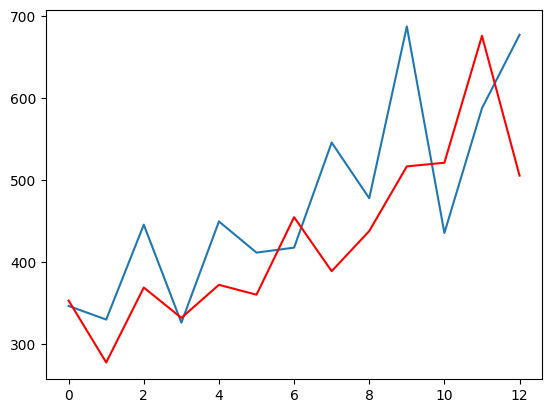

In [10]:
# statsmodels 라이브러리를 이용한 sales 데이터셋 예측

import numpy as np
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

def parser(x):
    return datetime.strptime('199'+x, '%Y-%m')

series = read_csv('sales.csv', header=0, parse_dates=[0], index_col=0,
                  date_parser=parser)

X = series.values
X = np.nan_to_num(X)
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)
    print('predicted=%f, expected=%f' % (yhat,obs))

error = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

데이터가 우상향 추세를 나타내고 있으므로, 자전거 판매가 향후에도 계속 증가할 것임을 예측할 수 있다. 이와같이 ARIMA를 사용할 경우 데이터 경향을 파악해 미래를 예측할 수 있다.

## **3. 순환 신경망(RNN)**

**RNN**(Recurrent Neural Network)는 시간적으로 연속성이 있는 데이터를 처리하려고 고안된 인공 신경망이다. RNN이 기존 네트워크와 다른 점은 **'기억(memory)'** 을 갖는다는 것이다. 이때, 기억은 현재까지 입력 데이터를 요약한 정보라고 생각하면 된다.

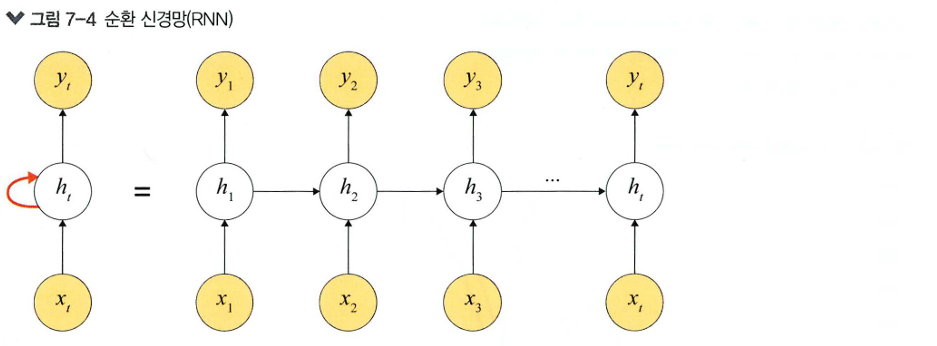

그림과 같이 첫 번째 입력($x_1$)이 들어오면 첫 번째 기억($h_1$)이 만들어지고, 두 번째 입력($x_2$)이 들어오면 기존 기억($h_1$)과 새로운 입력을 참고하여 새 기억($h_2$)을 만든다. 즉, **RNN은 외부 입력과 자신의 이전 상태를 입력받아 현재 상태를 갱신**한다.

RNN은 입력과 출력에 따라 일대일, 일대다, 다대일, 다대다, 동기화 다대다로 나눌 수 있다.

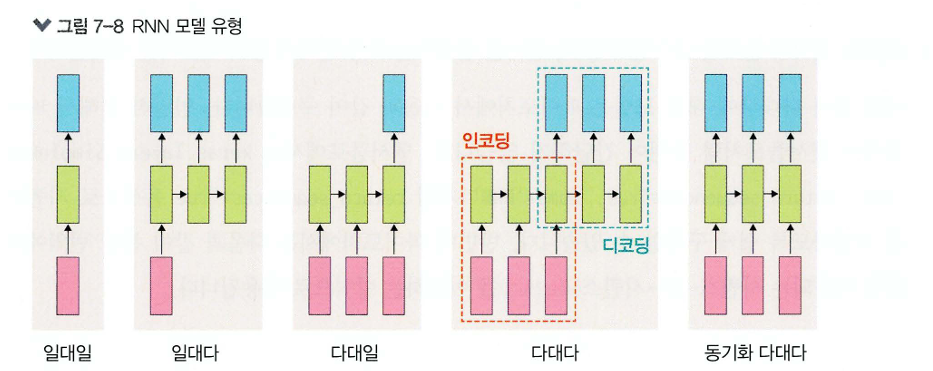

### **3.1. RNN 계층과 셀**

RNN은 내장된 계층뿐만 아니라 셀 레벨의 API도 제공한다. RNN 계층이 입력된 배치 순서대로 모두 처리하는 것과 다르게 RNN 셀은 오직 하나의 단계만 처리한다. 따라서, RNN 셀은 RNN 계층의 for loop 구문을 갖는 구조라고 할 수 있다.


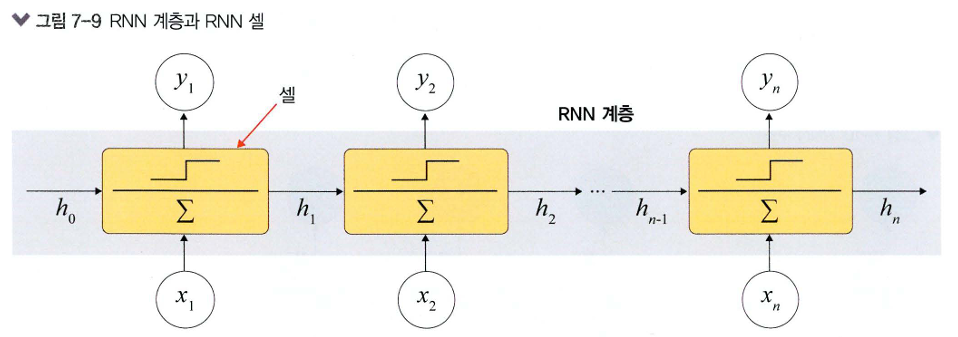

셀 유형은 다음과 같다.
- **nn.RNNCell**: SimpleRNN 계층에 대응되는 RNN 셀
- **nn.GRUCell**: GRU 계층에 대응되는 GRU 셀
- **nn.LSTMCell**: LSTM 계층에 대응되는 LSTM 셀

RNN의 활용 분야로는 대표적으로 '자연어 처리'를 꼽을 수 있다. 연속적인 단어들의 나열인 언어(자연어) 처리는 음성 인식, 단어의 의미 판단 및 대화 등에 대한 처리가 가능하다.

## **RNN 실습 코드**

### **1. 문자 단위 RNN(Char RNN)**

In [11]:
# library import

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

**훈련 데이터 전처리**

In [12]:
input_str = 'apple'
label_str = 'pple!'
char_vocab = sorted(list(set(input_str+label_str)))
vocab_size = len(char_vocab)
print('문자 집합의 크기: {}'.format(vocab_size))

문자 집합의 크기: 5


In [13]:
input_size = vocab_size
hidden_size = 5
output_size = 5
learning_rate = 0.1

In [14]:
# 문자 집합에 고유한 정수 부여

char_to_index = dict((c,i) for i, c in enumerate(char_vocab))
print(char_to_index)

{'!': 0, 'a': 1, 'e': 2, 'l': 3, 'p': 4}


In [15]:
index_to_char = {}
for key, value in char_to_index.items():
    index_to_char[value] = key
print(index_to_char)

{0: '!', 1: 'a', 2: 'e', 3: 'l', 4: 'p'}


In [17]:
x_data = [char_to_index[c] for c in input_str]
y_data = [char_to_index[c] for c in label_str]
print(x_data)
print(y_data)

[1, 4, 4, 3, 2]
[4, 4, 3, 2, 0]


In [18]:
# 배치 차원 추가 (nn.RNN은 3차원 텐서 입력)
# unsqueeze(0)을 통해 해결도 가능
x_data = [x_data]
y_data = [y_data]
print(x_data)
print(y_data)

[[1, 4, 4, 3, 2]]
[[4, 4, 3, 2, 0]]


In [19]:
# one-hot encoding

x_one_hot = [np.eye(vocab_size)[x] for x in x_data]
print(x_one_hot)

[array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.]])]


In [20]:
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

/tmp/ipython-input-2348034151.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.FloatTensor(x_one_hot)


In [21]:
print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기: {}'.format(Y.shape))

훈련 데이터의 크기: torch.Size([1, 5, 5])
레이블의 크기: torch.Size([1, 5])


**모델 구현하기**

In [22]:
class Net(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net, self).__init__()
        self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True) # RNN 셀 구현
        self.fc = torch.nn.Linear(hidden_size, output_size, bias=True) # 출력층 구현

    def forward(self, x): # 구현한 RNN 셀과 출력층을 연결
        x, _status = self.rnn(x)
        x = self.fc(x)
        return x

In [23]:
net = Net(input_size, hidden_size, output_size)

In [24]:
outputs = net(X)
print(outputs.shape)

torch.Size([1, 5, 5])


In [25]:
print(outputs.view(-1,input_size).shape)  # 2차원 텐서로 변환

torch.Size([5, 5])


In [26]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([1, 5])
torch.Size([5])


In [27]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [28]:
for i in range(100):
    optimizer.zero_grad()
    outputs = net(X)
    loss = criterion(outputs.view(-1,input_size), Y.view(-1))  # batch 차원 제거
    loss.backward()
    optimizer.step()

    result = outputs.data.numpy().argmax(axis=2)
    result_str = ''.join([index_to_char[c] for c in np.squeeze(result)])
    print(i, "loss: ", loss.item(), "predictions: ", result,
          "true Y: ", y_data, "prediction str: ", result_str)

0 loss:  1.6295254230499268 predictions:  [[4 0 4 1 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  p!pap
1 loss:  1.340346097946167 predictions:  [[4 4 4 0 4]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  ppp!p
2 loss:  1.1182234287261963 predictions:  [[4 4 4 2 3]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppel
3 loss:  0.8938682675361633 predictions:  [[4 4 4 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppe!
4 loss:  0.6769348382949829 predictions:  [[4 4 4 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppe!
5 loss:  0.5070702433586121 predictions:  [[4 4 4 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppe!
6 loss:  0.3877639174461365 predictions:  [[4 4 4 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppe!
7 loss:  0.29084688425064087 predictions:  [[4 4 4 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pppe!
8 loss:  0.21227960288524628 predictions:  [[4 4 3 2 0]] true Y:  [[4, 4, 3, 2, 0]] prediction str:  pple!
9 loss:  0.1563701182603836 predictions:  [[4

### **2. 더 많은 데이터로 학습한 문자 단위 RNN(Char RNN)**

In [1]:
# import library

import torch
import torch.nn as nn
import torch.optim as optim

**훈련 데이터 전처리하기**

In [2]:
sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")

In [3]:
char_set = list(set(sentence))
char_dic = {c: i for i, c in enumerate(char_set)}

In [4]:
print(char_dic)

{' ': 0, 'd': 1, 'i': 2, 'a': 3, "'": 4, 'h': 5, 'c': 6, 'y': 7, 'f': 8, 'g': 9, 'l': 10, 'k': 11, 'm': 12, '.': 13, 'e': 14, 'r': 15, ',': 16, 'u': 17, 'o': 18, 'n': 19, 'w': 20, 't': 21, 'b': 22, 'p': 23, 's': 24}


In [5]:
dic_size = len(char_dic)
print('문자 집합의 크기: {}'.format(dic_size))

문자 집합의 크기: 25


In [6]:
# hyperparameter 설정

hidden_size = dic_size
sequence_length = 10
learning_rate = 0.1

In [7]:
x_data = []
y_data = []

for i in range(0, len(sentence) - sequence_length):
    x_str = sentence[i:i+sequence_length]
    y_str = sentence[i+1: i+sequence_length+1]
    print(i, x_str, '->', y_str)

    x_data.append([char_dic[c] for c in x_str])
    y_data.append([char_dic[c] for c in y_str])

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

In [8]:
print(x_data[0])
print(y_data[0])

[2, 8, 0, 7, 18, 17, 0, 20, 3, 19]
[8, 0, 7, 18, 17, 0, 20, 3, 19, 21]


In [11]:
x_one_hot = [np.eye(dic_size)[x] for x in x_data]
X = torch.FloatTensor(x_one_hot)
Y = torch.LongTensor(y_data)

/tmp/ipython-input-2907341166.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.FloatTensor(x_one_hot)


In [12]:
print('훈련 데이터의 크기: {}'.format(X.shape))
print('레이블의 크기: {}'.format(Y.shape))

훈련 데이터의 크기: torch.Size([170, 10, 25])
레이블의 크기: torch.Size([170, 10])


In [13]:
print(X[0])

tensor([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,

In [14]:
print(Y[0])

tensor([ 8,  0,  7, 18, 17,  0, 20,  3, 19, 21])


**모델 구현하기**

In [15]:
class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, layers): # 현재 hidden_size는 dic_size와 같음.
        super(Net, self).__init__()
        self.rnn = torch.nn.RNN(input_dim, hidden_dim, num_layers=layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, hidden_dim, bias=True)

    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.fc(x)
        return x


In [16]:
net = Net(dic_size, hidden_size, 2)  # 이번에는 층을 두 개 쌓습니다.

In [17]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [18]:
outputs = net(X)
print(outputs.shape)  # 3차원 텐서

torch.Size([170, 10, 25])


In [19]:
print(outputs.view(-1, dic_size).shape)  # 2차원 텐서로 변환.

torch.Size([1700, 25])


In [20]:
print(Y.shape)
print(Y.view(-1).shape)

torch.Size([170, 10])
torch.Size([1700])


In [21]:
for i in range(100):
    optimizer.zero_grad()
    outputs = net(X) # (170, 10, 25) 크기를 가진 텐서를 매 에포크마다 모델의 입력으로 사용
    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    loss.backward()
    optimizer.step()

    # results의 텐서 크기는 (170, 10)
    results = outputs.argmax(dim=2)
    predict_str = ""
    for j, result in enumerate(results):
        if j == 0: # 처음에는 예측 결과를 전부 가져오지만
            predict_str += ''.join([char_set[t] for t in result])
        else: # 그 다음에는 마지막 글자만 반복 추가
            predict_str += char_set[result[-1]]

    print(predict_str)

  mb      mmmb  w bmm w   lwm   wmm wm mml l    mmmb  mm mmmb    mmbwm l  m wlmlw wmm w  b mmm  mmm  bm wlm wm mm wmmmmmm wmmmmw mmm  mmb  m wm  mmmm m  l m  m     w mb   mmm m  m
  l        l  s  slsl    s sl     l    l  s    l    s     l  s  l    l  s l   l     l  s   l    l  s  s   l         l      l  s       l  s        l       l   s  s   s  s  l       
                                                                                                                                    a                      a                       
thfs yfs bfbfffffffbfyffyfbffyffffbfffyfffyffffyyffyfffffffyfffbffffbfyffffffyfffffwffffbfffbyfffyfffbffyfbffsfyffffffftffffyfffyffffbfffffyffbfbfbffyffyfffyffbffffffffyfyfyfybfyf
tohotehestttetttettetetttetttetttetetteeettttetttteteeeteetete teetteeetteeetetetttetetteettete teeeteeetttettteeetttettet teeetteetteeetetetee ttteteetteeetteeeteetteee tteeetete
toeotetoh t o o tett toote otoo toeet toe t toet teooeoeoe hoeotoeo tootottettetoettont toe teo theo